=== Signalstärken im Sperrbereich (300–650 cm⁻¹) ===
  Background:  Ø = 1.01197
  Glass:       Ø = 0.00167  → 0.17% des BG
  NaCl:        Ø = 0.32204  → 31.82% des BG
Fertig.


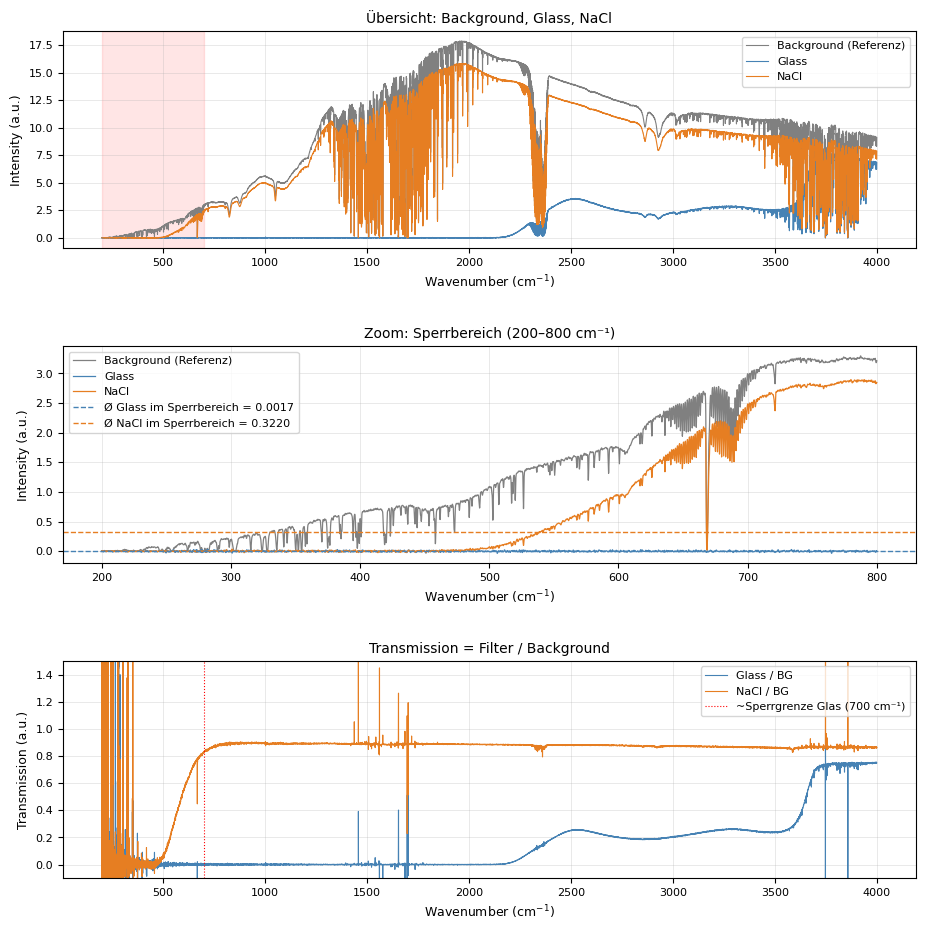

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def lese_asc(pfad):
    wn, it = [], []
    with open(pfad, "r", encoding="latin-1") as f:
        daten = False
        for zeile in f:
            z = zeile.strip()
            if z == "#DATA":
                daten = True; continue
            if daten and z:
                t = z.split()
                if len(t) == 2:
                    try:
                        wn.append(float(t[0]))
                        it.append(float(t[1]))
                    except ValueError:
                        pass
    wn, it = np.array(wn), np.array(it)
    return wn[np.argsort(wn)], it[np.argsort(wn)]

wn_bg, it_bg = lese_asc("1_1_1.asc")
wn_gl, it_gl = lese_asc("Glass.asc")
wn_na, it_na = lese_asc("NaCl.asc")

# Sperrbereich Glas: ~200–700 cm⁻¹  (Intensität fast 0)
# Sperrbereich NaCl: keine harte Grenze im MIR, aber deutlich gedämpft < 500 cm⁻¹
# Aufgabe: Signalstärke im Sperrbereich bestimmen

fig, axes = plt.subplots(3, 1, figsize=(11, 11))
plt.subplots_adjust(hspace=0.45)

daten = [
    (wn_bg, it_bg, "Background (Referenz)",       "gray"),
    (wn_gl, it_gl, "Glass",                        "steelblue"),
    (wn_na, it_na, "NaCl",                         "#e67e22"),
]

# Oben: alle drei übereinander zur Übersicht
ax = axes[0]
for wn, it, label, farbe in daten:
    m = (wn >= 200) & (wn <= 4000)
    ax.plot(wn[m], it[m], color=farbe, linewidth=0.8, label=label)
ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=9)
ax.set_ylabel("Intensity (a.u.)", fontsize=9)
ax.set_title("Übersicht: Background, Glass, NaCl", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.tick_params(labelsize=8)
# Sperrbereich markieren
ax.axvspan(200, 700, alpha=0.10, color="red", label="Sperrbereich Glas")

# Mitte: Zoom Sperrbereich Glas (200–800 cm⁻¹)
ax = axes[1]
for wn, it, label, farbe in daten:
    m = (wn >= 200) & (wn <= 800)
    if m.sum() > 0:
        ax.plot(wn[m], it[m], color=farbe, linewidth=0.9, label=label)

# Mittlere Signalstärke im Sperrbereich als horizontale Linie
m_gl = (wn_gl >= 300) & (wn_gl <= 650)
m_na = (wn_na >= 300) & (wn_na <= 650)
mean_gl = np.mean(it_gl[m_gl])
mean_na = np.mean(it_na[m_na])
ax.axhline(mean_gl, color="steelblue", linewidth=1.0, linestyle="--",
           label=f"Ø Glass im Sperrbereich = {mean_gl:.4f}")
ax.axhline(mean_na, color="#e67e22",   linewidth=1.0, linestyle="--",
           label=f"Ø NaCl im Sperrbereich = {mean_na:.4f}")

ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=9)
ax.set_ylabel("Intensity (a.u.)", fontsize=9)
ax.set_title("Zoom: Sperrbereich (200–800 cm⁻¹)", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.tick_params(labelsize=8)

# Unten: Verhältnis Signal_Filter / Signal_Background = "Wie viel kommt durch?"
ax = axes[2]
# interpoliere bg auf gl-Gitter im gemeinsamen Bereich
lo, hi = 200, 4000
m_gl2 = (wn_gl >= lo) & (wn_gl <= hi)
m_na2 = (wn_na >= lo) & (wn_na <= hi)
bg_auf_gl = np.interp(wn_gl[m_gl2], wn_bg, it_bg)
bg_auf_na = np.interp(wn_na[m_na2], wn_bg, it_bg)

ratio_gl = it_gl[m_gl2] / bg_auf_gl
ratio_na = it_na[m_na2] / bg_auf_na

ax.plot(wn_gl[m_gl2], ratio_gl, color="steelblue", linewidth=0.8, label="Glass / BG")
ax.plot(wn_na[m_na2], ratio_na, color="#e67e22",   linewidth=0.8, label="NaCl / BG")
ax.axvline(700, color="red", linewidth=0.8, linestyle=":", label="~Sperrgrenze Glas (700 cm⁻¹)")
ax.set_ylim(-0.1, 1.5)
ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=9)
ax.set_ylabel("Transmission (a.u.)", fontsize=9)
ax.set_title("Transmission = Filter / Background", fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, linewidth=0.4, alpha=0.5)
ax.tick_params(labelsize=8)

plt.savefig("aufgabe3_filter.png",
            dpi=130, bbox_inches="tight")

# Zahlenwerte für Protokoll
print("=== Signalstärken im Sperrbereich (300–650 cm⁻¹) ===")
m_bg2 = (wn_bg >= 300) & (wn_bg <= 650)
print(f"  Background:  Ø = {np.mean(it_bg[m_bg2]):.5f}")
print(f"  Glass:       Ø = {np.mean(it_gl[m_gl]):.5f}  → {100*np.mean(it_gl[m_gl])/np.mean(it_bg[m_bg2]):.2f}% des BG")
print(f"  NaCl:        Ø = {np.mean(it_na[m_na]):.5f}  → {100*np.mean(it_na[m_na])/np.mean(it_bg[m_bg2]):.2f}% des BG")
print("Fertig.")